# Customer Analytics — Purchase Probability & Price Elasticity Modelling
**Author:** Manzoor Syiemlieh
**Date:** 2025
**Tools:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn

## Objective
Build predictive models for Purchase Incidence, Brand Choice and Purchase Quantity using Logistic and Linear Regression. Run segment level price elasticity simulations to quantify customer price sensitivity and generate targeted pricing and promotional strategies.

## Dependencies
This notebook requires pickle models from 01_Segmentation.ipynb. Run that notebook first to generate scaler.pickle, pca.pickle and kmeans_pca.pickle in the models folder.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
import matplotlib.pyplot as plt
import matplotlib.axes as axs
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Loading Data and Assigning Segments
Loading purchase transaction data and applying pre-trained segmentation models to assign each customer to their segment.

In [2]:
raw_data = pd.read_csv("data/purchase_data.csv")
df_purchase = raw_data.copy()

In [3]:
scaler = pickle.load(open('models/scaler.pickle', 'rb'))
pca = pickle.load(open('models/pca.pickle', 'rb'))
kmeans_pca = pickle.load(open('models/kmeans_pca.pickle', 'rb'))

In [4]:
df_purchase.columns.values

array(['ID', 'Day', 'Incidence', 'Brand', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size'],
      dtype=object)

In [5]:
features = df_purchase[['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']]

purchase_std = scaler.transform(features)
purchase_pca = pca.transform(purchase_std)
purchase_kmeans_pca = kmeans_pca.predict(purchase_pca)

df_purchase_predictors = df_purchase.copy()
df_purchase_predictors['Segments'] = purchase_kmeans_pca

segment_dummies = pd.get_dummies(purchase_kmeans_pca, prefix='Segments', prefix_sep='_', dtype=int)
df_purchase_predictors = pd.concat([df_purchase_predictors, segment_dummies], axis=1)

df_pa = df_purchase_predictors.copy()
df_pa.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,Price_4,Price_5,Promotion_1,Promotion_2,Promotion_3,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segments,Segments_0,Segments_1,Segments_2,Segments_3
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,2.09,2.66,0,1,0,0,0,0,0,47,1,110866,1,0,0,1,0,0,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0,1,0,0,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0,1,0,0,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0,1,0,0,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,2.09,2.66,0,0,0,0,0,0,0,47,1,110866,1,0,0,1,0,0,0


## 3. Purchase Probability Model
Building a Logistic Regression model to predict the probability that a customer makes a purchase on any given shopping occasion.

**Target variable:** Incidence (1 = purchase made, 0 = no purchase)
**Key feature:** Mean price across all 5 brands

A negative coefficient confirms that higher prices reduce purchase probability — consistent with economic theory.

In [6]:
y = df_pa['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa['Price_1'] +
                   df_pa['Price_2'] +
                   df_pa['Price_3'] +
                   df_pa['Price_4'] +
                   df_pa['Price_5'] ) / 5

model_incidence = LogisticRegression()
model_incidence.fit(X, y)

model_incidence.coef_

array([[-2.35144634]])

In [7]:
df_pa[['Price_1', 'Price_2', 'Price_3', 'Price_4', 'Price_5']].describe()

,Price_1,Price_2,Price_3,Price_4,Price_5
count,58693.000000,58693.000000,58693.000000,58693.000000,58693.000000
mean,1.392074,1.780999,2.006789,2.159945,2.654798
std,0.091139,0.170868,0.046867,0.089825,0.098272
min,1.100000,1.260000,1.870000,1.760000,2.110000
25%,1.340000,1.580000,1.970000,2.120000,2.630000
50%,1.390000,1.880000,2.010000,2.170000,2.670000
75%,1.470000,1.890000,2.060000,2.240000,2.700000
max,1.590000,1.900000,2.140000,2.260000,2.800000


In [8]:
price_range = np.arange(0.5, 3.5, 0.01)
df_price_range = pd.DataFrame(price_range)

In [9]:
y_proba = model_incidence.predict_proba(df_price_range)
pred_proba = y_proba[:, 1]

In [10]:
pe = model_incidence.coef_[:,0] * price_range * (1 - pred_proba)

## 4. Price Elasticity of Purchase Probability
Calculating how sensitive purchase probability is to price changes.

**Formula:** PE = β × Price × (1 - Purchase Probability) 

**Interpretation:**
- All negative values confirm price sensitivity
- More negative = customers more sensitive to price increases
- Values closer to 0 = more inelastic demand

In [11]:
df_price_elasticity = pd.DataFrame(price_range)
df_price_elasticity = df_price_elasticity.rename(columns={0:'Price_Point'})
df_price_elasticity['Mean_PE'] = pe
df_price_elasticity

,Price_Point,Mean_PE
0,0.50,-0.096091
1,0.51,-0.100151
2,0.52,-0.104337
3,0.53,-0.108653
4,0.54,-0.113102
...,...,...
295,3.45,-8.024905
296,3.46,-8.050185
297,3.47,-8.075431
298,3.48,-8.100643


Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

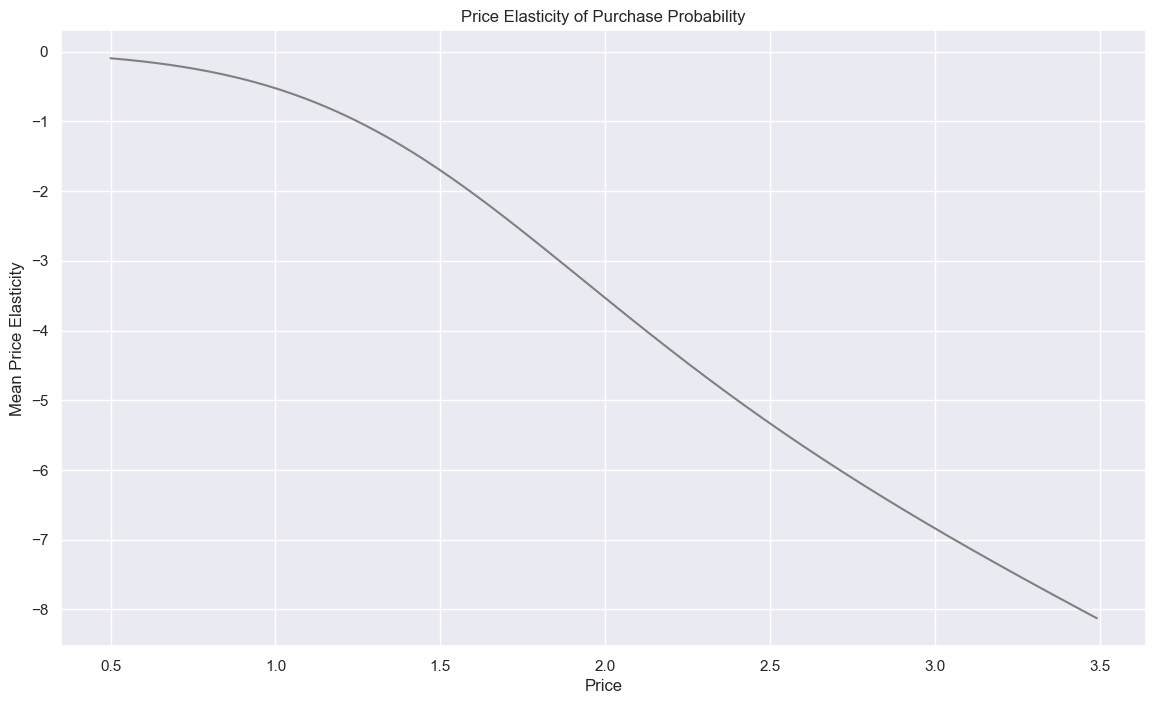

In [12]:
plt.figure(figsize=(14,8))
plt.plot(price_range, pe, c='gray')
plt.xlabel('Price')
plt.ylabel('Mean Price Elasticity')
plt.title('Price Elasticity of Purchase Probability')

### 4.1 Price Elasticity by Customer Segment
Running separate elasticity calculations for each of the 4 customer segments to understand how price sensitivity differs across customer groups.

Segment-level elasticity enables precision pricing — different price strategies for different customer groups based on their individual sensitivity profiles.

In [13]:
df_pa_segm0 = df_pa[df_pa['Segments'] == 0]

y = df_pa_segm0['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segm0['Price_1'] +
                   df_pa_segm0['Price_2'] +
                   df_pa_segm0['Price_3'] +
                   df_pa_segm0['Price_4'] +
                   df_pa_segm0['Price_5'] ) / 5

model_incidence_segm0 = LogisticRegression()
model_incidence_segm0.fit(X, y)

y_prob_segm0 = model_incidence_segm0.predict_proba(df_price_range)
pred_proba_segm0 = y_prob_segm0[:, 1]
pe_segm0 = model_incidence_segm0.coef_[:, 0] * price_range * (1 - pred_proba_segm0)

df_price_elasticity['PE_Segm0'] = pe_segm0
df_price_elasticity

,Price_Point,Mean_PE,PE_Segm0
0,0.50,-0.096091,-0.068383
1,0.51,-0.100151,-0.071418
2,0.52,-0.104337,-0.074557
3,0.53,-0.108653,-0.077802
4,0.54,-0.113102,-0.081156
...,...,...,...
295,3.45,-8.024905,-8.534409
296,3.46,-8.050185,-8.561408
297,3.47,-8.075431,-8.588366
298,3.48,-8.100643,-8.615283


In [14]:
df_pa_segm1 = df_pa[df_pa['Segments'] == 1]

y = df_pa_segm1['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segm1['Price_1'] +
                   df_pa_segm1['Price_2'] +
                   df_pa_segm1['Price_3'] +
                   df_pa_segm1['Price_4'] +
                   df_pa_segm1['Price_5'] ) / 5

model_incidence_segm1 = LogisticRegression()
model_incidence_segm1.fit(X, y)

y_prob_segm1 = model_incidence_segm1.predict_proba(df_price_range)
pred_proba_segm1 = y_prob_segm1[:, 1]
pe_segm1 = model_incidence_segm1.coef_[:, 0] * price_range * (1 - pred_proba_segm1)

df_price_elasticity['PE_Segm1'] = pe_segm1

In [15]:
df_pa_segm2 = df_pa[df_pa['Segments'] == 2]

y = df_pa_segm2['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segm2['Price_1'] +
                   df_pa_segm2['Price_2'] +
                   df_pa_segm2['Price_3'] +
                   df_pa_segm2['Price_4'] +
                   df_pa_segm2['Price_5'] ) / 5

model_incidence_segm2 = LogisticRegression()
model_incidence_segm2.fit(X, y)

y_prob_segm2 = model_incidence_segm2.predict_proba(df_price_range)
pred_proba_segm2 = y_prob_segm2[:, 1]
pe_segm2 = model_incidence_segm2.coef_[:, 0] * price_range * (1 - pred_proba_segm2)

df_price_elasticity['PE_Segm2'] = pe_segm2

In [16]:
df_pa_segm3 = df_pa[df_pa['Segments'] == 3]

y = df_pa_segm3['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segm3['Price_1'] +
                   df_pa_segm3['Price_2'] +
                   df_pa_segm3['Price_3'] +
                   df_pa_segm3['Price_4'] +
                   df_pa_segm3['Price_5'] ) / 5

model_incidence_segm3 = LogisticRegression()
model_incidence_segm3.fit(X, y)

y_prob_segm3 = model_incidence_segm3.predict_proba(df_price_range)
pred_proba_segm3 = y_prob_segm3[:, 1]
pe_segm3 = model_incidence_segm3.coef_[:, 0] * price_range * (1 - pred_proba_segm3)

df_price_elasticity['PE_Segm3'] = pe_segm3

In [17]:
df_price_elasticity

,Price_Point,Mean_PE,PE_Segm0,PE_Segm1,PE_Segm2,PE_Segm3
0,0.50,-0.096091,-0.068383,-0.095049,-0.177250,-0.158684
1,0.51,-0.100151,-0.071418,-0.099347,-0.183247,-0.163642
2,0.52,-0.104337,-0.074557,-0.103794,-0.189365,-0.168685
3,0.53,-0.108653,-0.077802,-0.108394,-0.195605,-0.173812
4,0.54,-0.113102,-0.081156,-0.113153,-0.201969,-0.179025
...,...,...,...,...,...,...
295,3.45,-8.024905,-8.534409,-9.039062,-5.735560,-4.637926
296,3.46,-8.050185,-8.561408,-9.066533,-5.754554,-4.654671
297,3.47,-8.075431,-8.588366,-9.093979,-5.773523,-4.671393
298,3.48,-8.100643,-8.615283,-9.121401,-5.792468,-4.688092


### Consolidated Visualisation Summary of Purchase Probaility 

Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

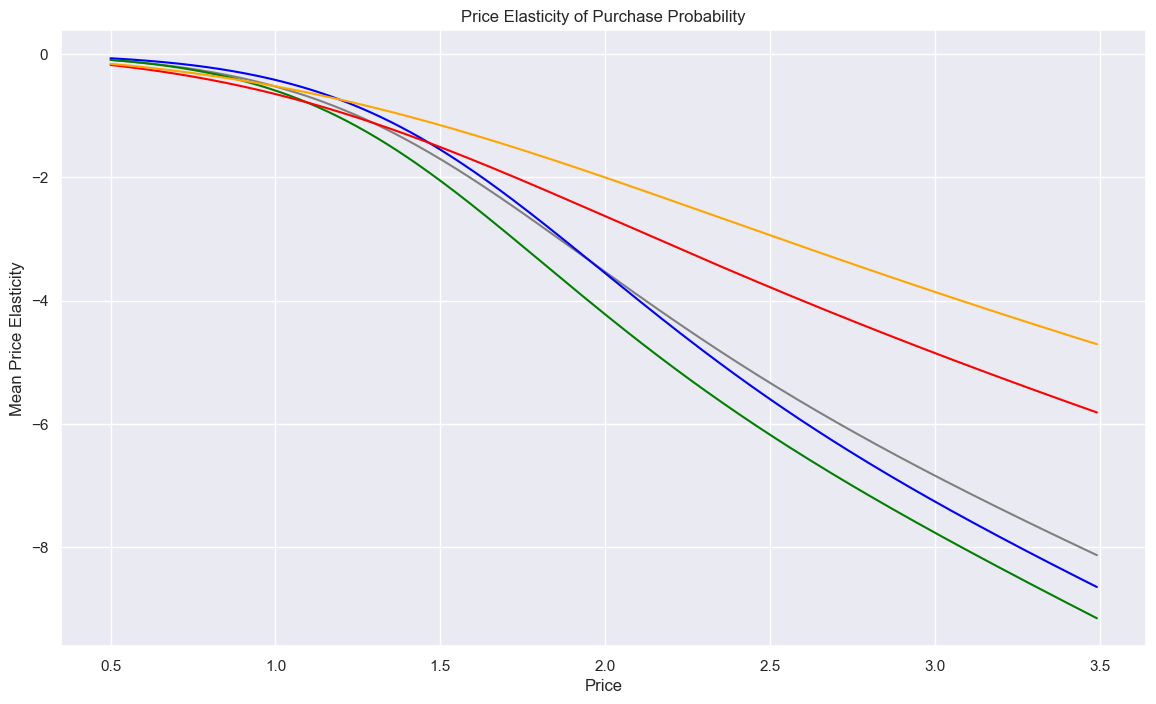

In [18]:
plt.figure(figsize=(14,8))
plt.plot(price_range, pe, c='gray')
plt.plot(price_range, pe_segm0, c='blue')
plt.plot(price_range, pe_segm1, c='green')
plt.plot(price_range, pe_segm2, c='red')
plt.plot(price_range, pe_segm3, c='orange')
plt.xlabel('Price')
plt.ylabel('Mean Price Elasticity')
plt.title('Price Elasticity of Purchase Probability')

### 4.2 Purchase Probability With and Without Promotion
Adding promotional flag as a feature to the incidence model to quantify the uplift effect of promotions on purchase probability.

Comparing elasticity curves with promotion active versus without promotion reveals the true incremental value of promotional spend at each price point.

In [19]:
y = df_pa['Incidence']
X = pd.DataFrame()
X['Mean_Price'] = (df_pa['Price_1'] +
                   df_pa['Price_2'] +
                   df_pa['Price_3'] +
                   df_pa['Price_4'] +
                   df_pa['Price_5'] ) / 5

X['Mean_Promotion'] = (df_pa['Promotion_1'] +
                       df_pa['Promotion_2'] +
                       df_pa['Promotion_3'] +
                       df_pa['Promotion_4'] +
                       df_pa['Promotion_5'] ) / 5

model_incidence_promotion = LogisticRegression()
model_incidence_promotion.fit(X, y)

model_incidence_promotion.coef_

array([[-1.50889842,  0.55637772]])

In [20]:
df_pe_with_promo = pd.DataFrame(price_range)
df_pe_with_promo = df_pe_with_promo.rename(columns={0: 'Price_Range'})
df_pe_with_promo['Promotion'] = 1
df_pe_with_promo = df_pe_with_promo.rename(columns={'Price_Range': 'Mean_Price',
                                                 'Promotion': 'Mean_Promotion'})

In [21]:
y_prob_promo = model_incidence_promotion.predict_proba(df_pe_with_promo)
pred_proba_promo = y_prob_promo[:, 1]
pe_with_promo = model_incidence_promotion.coef_[:, 0] * price_range * (1 - pred_proba_promo)

df_price_elasticity['PE_Promo'] = pe_with_promo

In [22]:
df_pe_no_promo = pd.DataFrame(price_range)
df_pe_no_promo = df_pe_no_promo.rename(columns={0:'Price_range'})
df_pe_no_promo['Promotion'] = 0
df_pe_no_promo = df_pe_no_promo.rename(columns={'Price_range': 'Mean_Price',
                                               'Promotion': 'Mean_Promotion'})

y_prob_no_promo = model_incidence_promotion.predict_proba(df_pe_no_promo)
pred_proba_no_promo = y_prob_no_promo[:, 1]
pe_no_promo = model_incidence_promotion.coef_[:, 0] * price_range * (1 - pred_proba_no_promo)

df_price_elasticity['PE_No_Promo'] = pe_no_promo

In [23]:
df_price_elasticity

,Price_Point,Mean_PE,PE_Segm0,PE_Segm1,PE_Segm2,PE_Segm3,PE_Promo,PE_No_Promo
0,0.50,-0.096091,-0.068383,-0.095049,-0.177250,-0.158684,-0.125074,-0.194207
1,0.51,-0.100151,-0.071418,-0.099347,-0.183247,-0.163642,-0.129189,-0.200319
2,0.52,-0.104337,-0.074557,-0.103794,-0.189365,-0.168685,-0.133385,-0.206535
3,0.53,-0.108653,-0.077802,-0.108394,-0.195605,-0.173812,-0.137661,-0.212855
4,0.54,-0.113102,-0.081156,-0.113153,-0.201969,-0.179025,-0.142019,-0.219281
...,...,...,...,...,...,...,...,...
295,3.45,-8.024905,-8.534409,-9.039062,-5.735560,-4.637926,-4.917098,-5.036241
296,3.46,-8.050185,-8.561408,-9.066533,-5.754554,-4.654671,-4.935448,-5.053302
297,3.47,-8.075431,-8.588366,-9.093979,-5.773523,-4.671393,-4.953767,-5.070343
298,3.48,-8.100643,-8.615283,-9.121401,-5.792468,-4.688092,-4.972055,-5.087364


### Consolidated Visualised Summary of Purchase Probability with and without Promotion 

Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

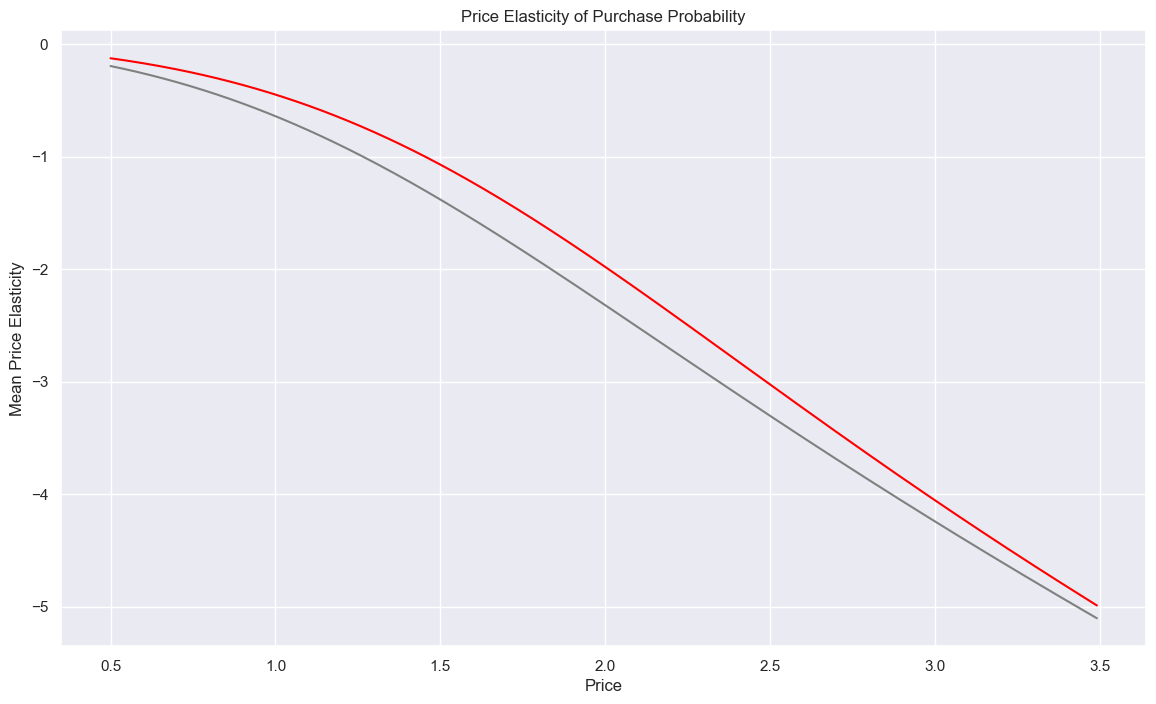

In [24]:
plt.figure(figsize=(14,8))
plt.plot(price_range, pe_no_promo, c='gray')
plt.plot(price_range, pe_with_promo, c='red')
plt.xlabel('Price')
plt.ylabel('Mean Price Elasticity')
plt.title('Price Elasticity of Purchase Probability')

## 5. Brand Choice Model — Own and Cross Price Elasticity
Building a Multinomial Logistic Regression model to predict which brand a customer chooses given they have already decided to make a purchase (conditioned on Incidence = 1).

**Own Price Elasticity:** How Brand 5 choice probability changes when Brand 5 price changes
**Cross Price Elasticity:** How Brand 5 choice probability changes when Brand 4 price changes

Positive cross elasticity confirms Brand 4 and Brand 5 are substitutes — raising Brand 4 price increases Brand 5 purchase probability.

In [25]:
brand_choice = df_pa[df_pa['Incidence'] == 1]
brand_choice.columns.values

array(['ID', 'Day', 'Incidence', 'Brand', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size', 'Segments',
       'Segments_0', 'Segments_1', 'Segments_2', 'Segments_3'],
      dtype=object)

In [26]:
y = brand_choice['Brand']
features = ['Price_1', 'Price_2', 'Price_3', 'Price_4', 'Price_5']
X = brand_choice[features]

model_bc = LogisticRegression(max_iter=1000)
model_bc.fit(X, y)

model_bc.coef_

array([[-3.88009388,  0.69328828,  2.58730995,  0.67199144, -0.1401519 ],
       [ 1.2773451 , -1.87662043, -0.19280293, -0.19108523,  0.63109243],
       [ 1.54594993,  0.52190212,  0.3020872 ,  0.96126922,  0.28753489],
       [ 0.59385313,  0.39887525, -1.37859961, -1.19624879,  0.28419161],
       [ 0.46294571,  0.26255478, -1.31799461, -0.24592664, -1.06266703]])

In [27]:
bc_coef = pd.DataFrame(np.transpose(model_bc.coef_))
coefficients = ['Coef_1', 'Coef_2', 'Coef_3', 'Coef_4', 'Coef_5']
bc_coef.columns = [coefficients]
prices = ['Price_1', 'Price_2', 'Price_3', 'Price_4', 'Price_5']
bc_coef.index = [prices]
bc_coef = bc_coef.round(2)
bc_coef

,Coef_1,Coef_2,Coef_3,Coef_4,Coef_5
Price_1,-3.88,1.28,1.55,0.59,0.46
Price_2,0.69,-1.88,0.52,0.40,0.26
Price_3,2.59,-0.19,0.30,-1.38,-1.32
Price_4,0.67,-0.19,0.96,-1.20,-0.25
Price_5,-0.14,0.63,0.29,0.28,-1.06


In [28]:
beta5 = bc_coef.iloc[4,4]
beta5

np.float64(-1.06)

### OWN Brand-5 and Cross Brand-4 Price Elasticity 

In [29]:
df_own_brand5 = pd.DataFrame(index=np.arange(price_range.size))
df_own_brand5['Price_1'] = brand_choice['Price_1'].mean()
df_own_brand5['Price_2'] = brand_choice['Price_2'].mean()
df_own_brand5['Price_3'] = brand_choice['Price_3'].mean()
df_own_brand5['Price_4'] = brand_choice['Price_4'].mean()
df_own_brand5['Price_5'] = price_range

y_prob_brand5 = model_bc.predict_proba(df_own_brand5)
pred_prob_brand5 = y_prob_brand5[:, 4]
pe_own_brand5 = beta5 * price_range * (1 - pred_prob_brand5)
df_price_elasticity['PE_Brand5'] = pe_own_brand5

In [30]:
df_brand5_cross_brand4 = pd.DataFrame(index=np.arange(price_range.size))
df_brand5_cross_brand4['Price_1'] = brand_choice['Price_1'].mean()
df_brand5_cross_brand4['Price_2'] = brand_choice['Price_2'].mean()
df_brand5_cross_brand4['Price_3'] = brand_choice['Price_3'].mean()
df_brand5_cross_brand4['Price_4'] = price_range
df_brand5_cross_brand4['Price_5'] = brand_choice['Price_5'].mean()

y_brand5_cross_brand4 = model_bc.predict_proba(df_brand5_cross_brand4)
pred_prob_brand5_cross_brand4 = y_brand5_cross_brand4[:, 3]
pe_brand5_cross_brand4 = -beta5 * price_range * pred_prob_brand5_cross_brand4
df_price_elasticity['PE_Cross_Brand4'] = pe_brand5_cross_brand4

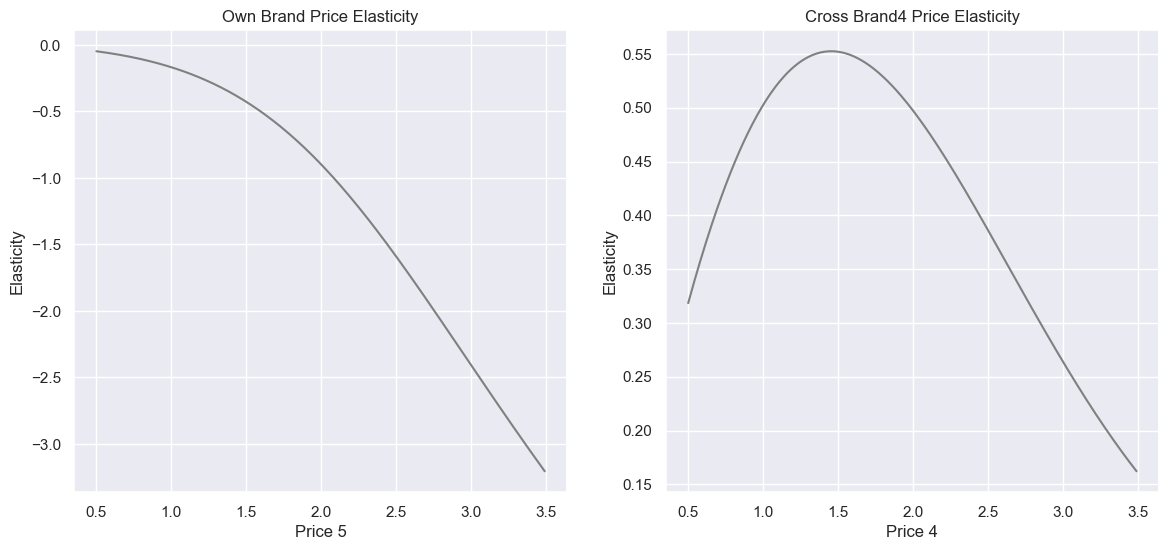

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))
axs[0].plot(price_range, pe_own_brand5, color='gray')
axs[0].set_xlabel('Price 5')
axs[0].set_title('Own Brand Price Elasticity')
axs[1].plot(price_range, pe_brand5_cross_brand4, color='gray')
axs[1].set_xlabel('Price 4')
axs[1].set_title('Cross Brand4 Price Elasticity')

for ax in axs.flat:
    ax.set(ylabel = 'Elasticity')

### 5.1 Brand Choice Elasticity — Segment 0 (Career-Focused)

In [32]:
brand_choice_s0 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s0 = brand_choice_s0[brand_choice_s0['Segments'] == 0]

y = brand_choice_s0['Brand']
brand_choice_s0 = pd.get_dummies(brand_choice_s0, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s0[features]

model_bc_s0 = LogisticRegression(max_iter=1000)
model_bc_s0.fit(X, y)
model_bc_s0.coef_

bc_coef = pd.DataFrame(np.transpose(model_bc_s0.coef_)) 
bc_coef.columns = [coefficients] 
bc_coef.index = [prices] 
bc_coef = bc_coef.round(2) 
bc_coef 

,Coef_1,Coef_2,Coef_3,Coef_4,Coef_5
Price_1,-3.31,1.44,0.55,0.53,0.79
Price_2,0.83,-1.72,0.11,0.40,0.37
Price_3,0.88,0.96,1.01,-1.94,-0.91
Price_4,0.44,-0.15,1.09,-1.32,-0.07
Price_5,0.01,0.59,-0.31,0.36,-0.65


In [33]:
beta_s0 = bc_coef.iloc[4,4]
beta_s0

np.float64(-0.65)

In [34]:
df_own_brand5_s0 = pd.DataFrame(index=np.arange(price_range.size)) 
df_own_brand5_s0['Price_1'] = brand_choice_s0['Price_1'].mean() 
df_own_brand5_s0['Price_2'] = brand_choice_s0['Price_2'].mean() 
df_own_brand5_s0['Price_3'] = brand_choice_s0['Price_3'].mean() 
df_own_brand5_s0['Price_4'] = brand_choice_s0['Price_4'].mean() 
df_own_brand5_s0['Price_5'] = price_range 

y_prob_brand5_s0 = model_bc_s0.predict_proba(df_own_brand5_s0) 
pred_prob_brand5_s0 = y_prob_brand5_s0[:, 4] 
pe_own_brand5_s0 = beta_s0 * price_range * (1 - pred_prob_brand5_s0) 
df_price_elasticity['PE_Brand5_S0'] = pe_own_brand5_s0

In [35]:
df_brand5_cross_brand4_s0 = pd.DataFrame(index=np.arange(price_range.size)) 
df_brand5_cross_brand4_s0['Price_1'] = brand_choice_s0['Price_1'].mean() 
df_brand5_cross_brand4_s0['Price_2'] = brand_choice_s0['Price_2'].mean() 
df_brand5_cross_brand4_s0['Price_3'] = brand_choice_s0['Price_3'].mean() 
df_brand5_cross_brand4_s0['Price_4'] = price_range
df_brand5_cross_brand4_s0['Price_5'] = brand_choice_s0['Price_5'].mean() 

y_brand5_cross_brand4_s0 = model_bc_s0.predict_proba(df_brand5_cross_brand4_s0) 
pred_prob_brand5_cross_brand4_s0 = y_brand5_cross_brand4_s0[:, 3] 
pe_brand5_cross_brand4_s0 = -beta_s0 * price_range * pred_prob_brand5_cross_brand4_s0 
df_price_elasticity['PE_Cross_Brand4_S0'] = pe_brand5_cross_brand4_s0

### 5.2 Brand Choice Elasticity — Segment 1 (Fewer-Opportunities)

In [36]:
brand_choice_s1 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s1 = brand_choice_s1[brand_choice_s1['Segments'] == 1]

y = brand_choice_s1['Brand']
brand_choice_s1 = pd.get_dummies(brand_choice_s1, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s1[features]

model_bc_s1 = LogisticRegression(max_iter=1000)
model_bc_s1.fit(X, y)
model_bc_s1.coef_

bc_coef = pd.DataFrame(np.transpose(model_bc_s1.coef_)) 
bc_coef.columns = [coefficients] 
bc_coef.index = [prices] 
bc_coef = bc_coef.round(2) 
bc_coef 

,Coef_1,Coef_2,Coef_3,Coef_4,Coef_5
Price_1,-3.66,1.14,1.38,0.43,0.71
Price_2,0.40,-2.17,0.28,0.39,1.12
Price_3,1.63,-0.27,0.10,-0.22,-1.24
Price_4,1.21,-0.10,1.05,-1.47,-0.68
Price_5,0.64,0.95,0.70,0.25,-2.54


In [37]:
beta_s1 = bc_coef.iloc[4,4]
beta_s1

np.float64(-2.54)

In [38]:
df_own_brand5_s1 = pd.DataFrame(index=np.arange(price_range.size)) 
df_own_brand5_s1['Price_1'] = brand_choice_s1['Price_1'].mean() 
df_own_brand5_s1['Price_2'] = brand_choice_s1['Price_2'].mean() 
df_own_brand5_s1['Price_3'] = brand_choice_s1['Price_3'].mean() 
df_own_brand5_s1['Price_4'] = brand_choice_s1['Price_4'].mean() 
df_own_brand5_s1['Price_5'] = price_range 

y_prob_brand5_s1 = model_bc_s0.predict_proba(df_own_brand5_s1) 
pred_prob_brand5_s1 = y_prob_brand5_s1[:, 4] 
pe_own_brand5_s1 = beta_s1 * price_range * (1 - pred_prob_brand5_s1) 
df_price_elasticity['PE_Brand5_S1'] = pe_own_brand5_s1

In [39]:
df_brand5_cross_brand4_s1 = pd.DataFrame(index=np.arange(price_range.size)) 
df_brand5_cross_brand4_s1['Price_1'] = brand_choice_s1['Price_1'].mean() 
df_brand5_cross_brand4_s1['Price_2'] = brand_choice_s1['Price_2'].mean() 
df_brand5_cross_brand4_s1['Price_3'] = brand_choice_s1['Price_3'].mean() 
df_brand5_cross_brand4_s1['Price_4'] = price_range
df_brand5_cross_brand4_s1['Price_5'] = brand_choice_s1['Price_5'].mean() 

y_brand5_cross_brand4_s1 = model_bc_s1.predict_proba(df_brand5_cross_brand4_s1) 
pred_prob_brand5_cross_brand4_s1 = y_brand5_cross_brand4_s1[:, 3] 
pe_brand5_cross_brand4_s1 = -beta_s1 * price_range * pred_prob_brand5_cross_brand4_s1 
df_price_elasticity['PE_Cross_Brand4_S1'] = pe_brand5_cross_brand4_s1

### 5.3 Brand Choice Elasticity — Segment 2 (Standard)

In [40]:
brand_choice_s2 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s2 = brand_choice_s2[brand_choice_s2['Segments'] == 2]

y = brand_choice_s2['Brand']
brand_choice_s2 = pd.get_dummies(brand_choice_s2, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s2[features]

model_bc_s2 = LogisticRegression(max_iter=1000)
model_bc_s2.fit(X, y)
model_bc_s2.coef_

bc_coef = pd.DataFrame(np.transpose(model_bc_s2.coef_)) 
bc_coef.columns = [coefficients] 
bc_coef.index = [prices] 
bc_coef = bc_coef.round(2) 
bc_coef 

,Coef_1,Coef_2,Coef_3,Coef_4,Coef_5
Price_1,-2.80,1.30,1.43,-0.17,0.23
Price_2,1.31,-1.85,0.40,0.11,0.03
Price_3,0.92,-0.62,0.23,0.12,-0.64
Price_4,0.39,-0.32,0.82,-1.03,0.14
Price_5,-0.30,1.12,0.30,-0.28,-0.85


In [41]:
beta_s2 = bc_coef.iloc[4,4]
beta_s2

np.float64(-0.85)

In [42]:
df_own_brand5_s2 = pd.DataFrame(index=np.arange(price_range.size)) 
df_own_brand5_s2['Price_1'] = brand_choice_s2['Price_1'].mean() 
df_own_brand5_s2['Price_2'] = brand_choice_s2['Price_2'].mean() 
df_own_brand5_s2['Price_3'] = brand_choice_s2['Price_3'].mean() 
df_own_brand5_s2['Price_4'] = brand_choice_s2['Price_4'].mean() 
df_own_brand5_s2['Price_5'] = price_range 

y_prob_brand5_s2 = model_bc_s2.predict_proba(df_own_brand5_s2) 
pred_prob_brand5_s2 = y_prob_brand5_s2[:, 4] 
pe_own_brand5_s2 = beta_s2 * price_range * (1 - pred_prob_brand5_s2) 
df_price_elasticity['PE_Brand5_S2'] = pe_own_brand5_s2

In [43]:
df_brand5_cross_brand4_s2 = pd.DataFrame(index=np.arange(price_range.size)) 
df_brand5_cross_brand4_s2['Price_1'] = brand_choice_s2['Price_1'].mean() 
df_brand5_cross_brand4_s2['Price_2'] = brand_choice_s2['Price_2'].mean() 
df_brand5_cross_brand4_s2['Price_3'] = brand_choice_s2['Price_3'].mean() 
df_brand5_cross_brand4_s2['Price_4'] = price_range
df_brand5_cross_brand4_s2['Price_5'] = brand_choice_s2['Price_5'].mean() 

y_brand5_cross_brand4_s2 = model_bc_s2.predict_proba(df_brand5_cross_brand4_s2) 
pred_prob_brand5_cross_brand4_s2 = y_brand5_cross_brand4_s2[:, 3] 
pe_brand5_cross_brand4_s2 = -beta_s2 * price_range * pred_prob_brand5_cross_brand4_s2 
df_price_elasticity['PE_Cross_Brand4_S2'] = pe_brand5_cross_brand4_s2

### 5.4 Brand Choice Elasticity — Segment 3 (Well-Off)

In [44]:
brand_choice_s3 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s3 = brand_choice_s3[brand_choice_s3['Segments'] == 3]

y = brand_choice_s3['Brand']
brand_choice_s3 = pd.get_dummies(brand_choice_s3, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s3[features]

model_bc_s3 = LogisticRegression(max_iter=1000)
model_bc_s3.fit(X, y)
model_bc_s3.coef_

bc_coef = pd.DataFrame(np.transpose(model_bc_s3.coef_)) 
bc_coef.columns = [coefficients] 
bc_coef.index = [prices] 
bc_coef = bc_coef.round(2) 
bc_coef 

,Coef_1,Coef_2,Coef_3,Coef_4,Coef_5
Price_1,-2.19,1.24,0.76,0.29,-0.09
Price_2,-0.91,-1.40,1.25,0.77,0.29
Price_3,2.04,-1.57,-0.45,-0.01,-0.00
Price_4,2.62,0.58,-0.18,-1.74,-1.28
Price_5,-0.87,-0.34,1.04,0.56,-0.39


In [45]:
beta_s3 = bc_coef.iloc[4,4]
beta_s3

np.float64(-0.39)

In [46]:
df_own_brand5_s3 = pd.DataFrame(index=np.arange(price_range.size)) 
df_own_brand5_s3['Price_1'] = brand_choice_s3['Price_1'].mean() 
df_own_brand5_s3['Price_2'] = brand_choice_s3['Price_2'].mean() 
df_own_brand5_s3['Price_3'] = brand_choice_s3['Price_3'].mean() 
df_own_brand5_s3['Price_4'] = brand_choice_s3['Price_4'].mean() 
df_own_brand5_s3['Price_5'] = price_range 

y_prob_brand5_s3 = model_bc_s3.predict_proba(df_own_brand5_s3) 
pred_prob_brand5_s3 = y_prob_brand5_s3[:, 4] 
pe_own_brand5_s3 = beta_s3 * price_range * (1 - pred_prob_brand5_s3) 
df_price_elasticity['PE_Brand5_S3'] = pe_own_brand5_s3

In [47]:
df_brand5_cross_brand4_s3 = pd.DataFrame(index=np.arange(price_range.size)) 
df_brand5_cross_brand4_s3['Price_1'] = brand_choice_s3['Price_1'].mean() 
df_brand5_cross_brand4_s3['Price_2'] = brand_choice_s3['Price_2'].mean() 
df_brand5_cross_brand4_s3['Price_3'] = brand_choice_s3['Price_3'].mean() 
df_brand5_cross_brand4_s3['Price_4'] = price_range
df_brand5_cross_brand4_s3['Price_5'] = brand_choice_s3['Price_5'].mean() 

y_brand5_cross_brand4_s3 = model_bc_s3.predict_proba(df_brand5_cross_brand4_s3) 
pred_prob_brand5_cross_brand4_s3 = y_brand5_cross_brand4_s3[:, 3] 
pe_brand5_cross_brand4_s3 = -beta_s3 * price_range * pred_prob_brand5_cross_brand4_s3
df_price_elasticity['PE_Cross_Brand4_S3'] = pe_brand5_cross_brand4_s3

In [48]:
df_price_elasticity

,Price_Point,Mean_PE,PE_Segm0,PE_Segm1,PE_Segm2,PE_Segm3,PE_Promo,PE_No_Promo,PE_Brand5,PE_Cross_Brand4,PE_Brand5_S0,PE_Cross_Brand4_S0,PE_Brand5_S1,PE_Cross_Brand4_S1,PE_Brand5_S2,PE_Cross_Brand4_S2,PE_Brand5_S3,PE_Cross_Brand4_S3
0,0.50,-0.096091,-0.068383,-0.095049,-0.177250,-0.158684,-0.125074,-0.194207,-0.047146,0.318478,-0.021017,0.125741,-0.083664,0.536829,-0.103110,0.131305,-0.109683,0.168194
1,0.51,-0.100151,-0.071418,-0.099347,-0.183247,-0.163642,-0.129189,-0.200319,-0.048655,0.323532,-0.021611,0.127280,-0.086027,0.543710,-0.105737,0.133055,-0.111933,0.171435
2,0.52,-0.104337,-0.074557,-0.103794,-0.189365,-0.168685,-0.133385,-0.206535,-0.050192,0.328530,-0.022212,0.128784,-0.088425,0.550443,-0.108389,0.134772,-0.114187,0.174671
3,0.53,-0.108653,-0.077802,-0.108394,-0.195605,-0.173812,-0.137661,-0.212855,-0.051758,0.333473,-0.022823,0.130252,-0.090856,0.557028,-0.111067,0.136458,-0.116444,0.177901
4,0.54,-0.113102,-0.081156,-0.113153,-0.201969,-0.179025,-0.142019,-0.219281,-0.053354,0.338362,-0.023442,0.131685,-0.093321,0.563467,-0.113770,0.138112,-0.118706,0.181126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3.45,-8.024905,-8.534409,-9.039062,-5.735560,-4.637926,-4.917098,-5.036241,-3.142549,0.169507,-1.292654,0.031520,-5.112409,0.059067,-2.606892,0.043463,-1.184808,0.062425
296,3.46,-8.050185,-8.561408,-9.066533,-5.754554,-4.654671,-4.935448,-5.053302,-3.158296,0.167675,-1.302549,0.031185,-5.151195,0.057991,-2.619062,0.042998,-1.189515,0.060299
297,3.47,-8.075431,-8.588366,-9.093979,-5.773523,-4.671393,-4.953767,-5.070343,-3.174012,0.165855,-1.312470,0.030853,-5.190083,0.056931,-2.631210,0.042537,-1.194221,0.058235
298,3.48,-8.100643,-8.615283,-9.121401,-5.792468,-4.688092,-4.972055,-5.087364,-3.189697,0.164048,-1.322419,0.030523,-5.229072,0.055887,-2.643335,0.042079,-1.198927,0.056234


### Consolidated Visualised Summary of Brand Choice 

Text(0.5, 0, 'Price 4')

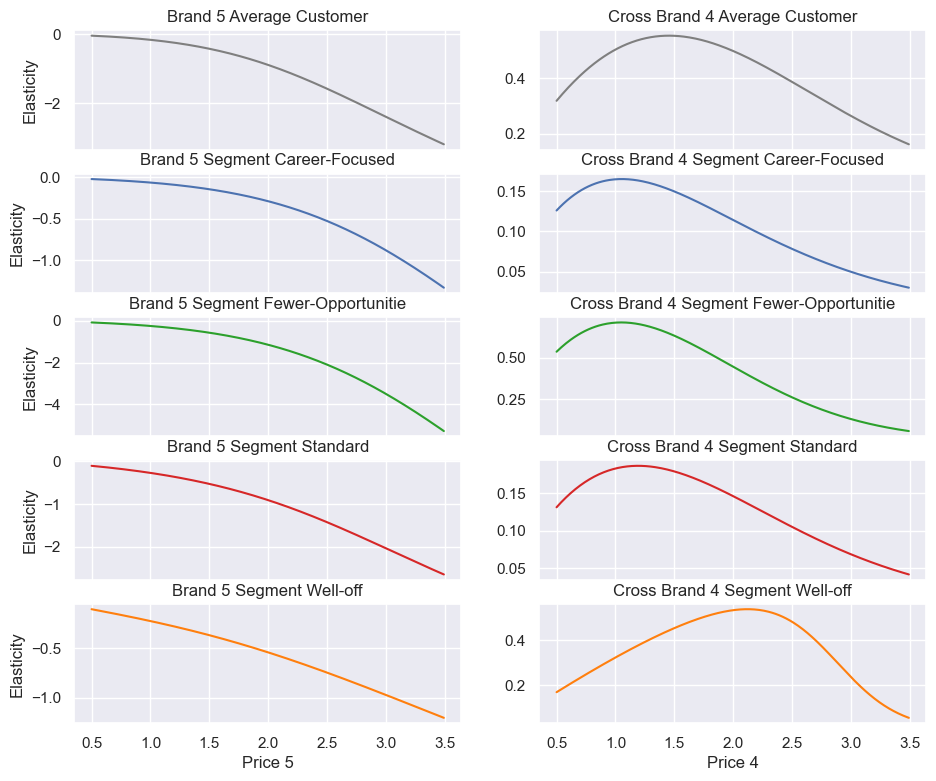

In [49]:
fig1, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 2, figsize = (11, 9), sharex = True)
ax1[0].plot(price_range, pe_own_brand5, 'tab:grey')
ax1[0].set_title('Brand 5 Average Customer')
ax1[0].set_ylabel('Elasticity')
ax1[1].plot(price_range, pe_brand5_cross_brand4, 'tab:grey')
ax1[1].set_title('Cross Brand 4 Average Customer')


ax2[0].plot(price_range, pe_own_brand5_s0)
ax2[0].set_title('Brand 5 Segment Career-Focused')
ax2[0].set_ylabel('Elasticity')
ax2[1].plot(price_range, pe_brand5_cross_brand4_s0)
ax2[1].set_title('Cross Brand 4 Segment Career-Focused')

ax3[0].plot(price_range, pe_own_brand5_s1, 'tab:green')
ax3[0].set_title('Brand 5 Segment Fewer-Opportunitie')
ax3[0].set_ylabel('Elasticity')
ax3[1].plot(price_range, pe_brand5_cross_brand4_s1, 'tab:green')
ax3[1].set_title('Cross Brand 4 Segment Fewer-Opportunitie')

ax4[0].plot(price_range, pe_own_brand5_s2, 'tab:red')
ax4[0].set_title('Brand 5 Segment Standard')
ax4[0].set_ylabel('Elasticity')
ax4[1].plot(price_range, pe_brand5_cross_brand4_s2, 'tab:red')
ax4[1].set_title('Cross Brand 4 Segment Standard')

ax5[0].plot(price_range, pe_own_brand5_s3, 'tab:orange')
ax5[0].set_title('Brand 5 Segment Well-off')
ax5[0].set_xlabel('Price 5')
ax5[0].set_ylabel('Elasticity')
ax5[1].plot(price_range, pe_brand5_cross_brand4_s3, 'tab:orange')
ax5[1].set_title('Cross Brand 4 Segment Well-off')
ax5[1].set_xlabel('Price 4')

## 6. Purchase Quantity Model
Building a Linear Regression model to predict how many units a customer purchases given they have decided to buy.

**Features:** Mean price across brands, promotional flag
**Target:** Quantity purchased

Comparing quantity elasticity with and without promotion shows how promotions influence not just the decision to buy but also how much customers buy.

In [50]:
df_purchase_quantity = df_pa[df_pa['Incidence'] == 1]
df_purchase_quantity = pd.get_dummies(df_purchase_quantity, columns=['Brand'], prefix='Brand', prefix_sep='_', dtype=int)
df_purchase_quantity.columns.values

array(['ID', 'Day', 'Incidence', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size', 'Segments',
       'Segments_0', 'Segments_1', 'Segments_2', 'Segments_3', 'Brand_1',
       'Brand_2', 'Brand_3', 'Brand_4', 'Brand_5'], dtype=object)

In [51]:
df_purchase_quantity['Price_Incidence'] = (df_purchase_quantity['Brand_1'] * df_purchase_quantity['Price_1'] +
                                df_purchase_quantity['Brand_2'] * df_purchase_quantity['Price_2'] +
                                df_purchase_quantity['Brand_3'] * df_purchase_quantity['Price_3'] +
                                df_purchase_quantity['Brand_4'] * df_purchase_quantity['Price_4'] +
                                df_purchase_quantity['Brand_5'] * df_purchase_quantity['Price_5'] )

df_purchase_quantity['Promotion_Incidence'] = (df_purchase_quantity['Brand_1'] * df_purchase_quantity['Promotion_1'] +
                                               df_purchase_quantity['Brand_2'] * df_purchase_quantity['Promotion_2'] +
                                               df_purchase_quantity['Brand_3'] * df_purchase_quantity['Promotion_3'] +
                                               df_purchase_quantity['Brand_4'] * df_purchase_quantity['Promotion_4'] +
                                               df_purchase_quantity['Brand_5'] * df_purchase_quantity['Promotion_5'] )


In [52]:
y = df_purchase_quantity['Quantity']
X = df_purchase_quantity[['Price_Incidence', 'Promotion_Incidence']]

model_quantity = LinearRegression()
model_quantity.fit(X, y)

model_quantity.coef_

array([-0.8173651 , -0.10504673])

#### Probability of Purchase Quantity With & Without Promotion 

In [53]:
df_pe_quantity = pd.DataFrame(index=np.arange(price_range.size))
df_pe_quantity['Price_Incidence'] = price_range
df_pe_quantity['Promotion_Incidence'] = 1

In [54]:
prob_quantity_promotion_yes = model_quantity.predict(df_pe_quantity)
beta_quantity = model_quantity.coef_[0]
pe_quantity_promotion_yes = beta_quantity * price_range / prob_quantity_promotion_yes
df_price_elasticity['PE_Quantity_Promotion_Yes'] = pe_quantity_promotion_yes

In [55]:
df_pe_quantity['Promotion_Incidence'] = 0

prob_quantity_promotion_no = model_quantity.predict(df_pe_quantity)
beta_quantity = model_quantity.coef_[0]
pe_quantity_promotion_no = beta_quantity * price_range / prob_quantity_promotion_no
df_price_elasticity['PE_Quantity_Promotion_No'] = pe_quantity_promotion_no

In [56]:
df_price_elasticity

,Price_Point,Mean_PE,PE_Segm0,PE_Segm1,PE_Segm2,PE_Segm3,PE_Promo,PE_No_Promo,PE_Brand5,PE_Cross_Brand4,PE_Brand5_S0,PE_Cross_Brand4_S0,PE_Brand5_S1,PE_Cross_Brand4_S1,PE_Brand5_S2,PE_Cross_Brand4_S2,PE_Brand5_S3,PE_Cross_Brand4_S3,PE_Quantity_Promotion_Yes,PE_Quantity_Promotion_No
0,0.50,-0.096091,-0.068383,-0.095049,-0.177250,-0.158684,-0.125074,-0.194207,-0.047146,0.318478,-0.021017,0.125741,-0.083664,0.536829,-0.103110,0.131305,-0.109683,0.168194,-0.102157,-0.099543
1,0.51,-0.100151,-0.071418,-0.099347,-0.183247,-0.163642,-0.129189,-0.200319,-0.048655,0.323532,-0.021611,0.127280,-0.086027,0.543710,-0.105737,0.133055,-0.111933,0.171435,-0.104413,-0.101736
2,0.52,-0.104337,-0.074557,-0.103794,-0.189365,-0.168685,-0.133385,-0.206535,-0.050192,0.328530,-0.022212,0.128784,-0.088425,0.550443,-0.108389,0.134772,-0.114187,0.174671,-0.106679,-0.103939
3,0.53,-0.108653,-0.077802,-0.108394,-0.195605,-0.173812,-0.137661,-0.212855,-0.051758,0.333473,-0.022823,0.130252,-0.090856,0.557028,-0.111067,0.136458,-0.116444,0.177901,-0.108954,-0.106150
4,0.54,-0.113102,-0.081156,-0.113153,-0.201969,-0.179025,-0.142019,-0.219281,-0.053354,0.338362,-0.023442,0.131685,-0.093321,0.563467,-0.113770,0.138112,-0.118706,0.181126,-0.111238,-0.108369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,3.45,-8.024905,-8.534409,-9.039062,-5.735560,-4.637926,-4.917098,-5.036241,-3.142549,0.169507,-1.292654,0.031520,-5.112409,0.059067,-2.606892,0.043463,-1.184808,0.062425,-1.774292,-1.664290
296,3.46,-8.050185,-8.561408,-9.066533,-5.754554,-4.654671,-4.935448,-5.053302,-3.158296,0.167675,-1.302549,0.031185,-5.151195,0.057991,-2.619062,0.042998,-1.189515,0.060299,-1.788634,-1.677205
297,3.47,-8.075431,-8.588366,-9.093979,-5.773523,-4.671393,-4.953767,-5.070343,-3.174012,0.165855,-1.312470,0.030853,-5.190083,0.056931,-2.631210,0.042537,-1.194221,0.058235,-1.803124,-1.690246
298,3.48,-8.100643,-8.615283,-9.121401,-5.792468,-4.688092,-4.972055,-5.087364,-3.189697,0.164048,-1.322419,0.030523,-5.229072,0.055887,-2.643335,0.042079,-1.198927,0.056234,-1.817766,-1.703414


### Consolidated Visualized Summary Of Purchase Quantity with and without Promotion 

Text(0.5, 1.0, 'Purchase Probability of Quantity With & Without Promotion')

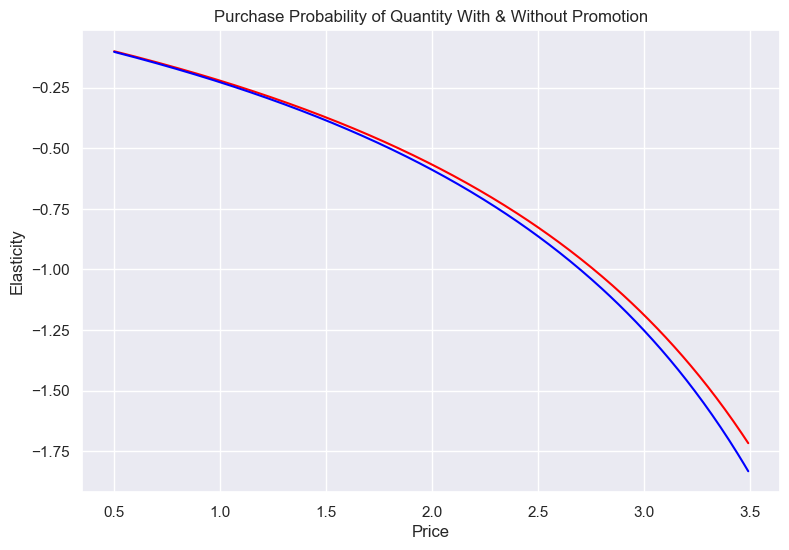

In [57]:
plt.figure(figsize=(9,6))
plt.plot(price_range, pe_quantity_promotion_no, c='red')
plt.plot(price_range, pe_quantity_promotion_yes, c='blue')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Purchase Probability of Quantity With & Without Promotion')

## 8. Summary and Key Findings

### What We Built
- Purchase Probability model — Logistic Regression on 58,693 shopping occasions
- Price Elasticity of Purchase Probability — overall, by segment, with and without promotion
- Brand Choice model — Own and Cross Price Elasticity overall and for all 4 customer segments
- Purchase Quantity model — Linear Regression with promotional impact analysis

### Key Business Insights
- Purchase probability is price elastic — customers respond meaningfully to price changes
- Elasticity varies significantly across segments — enabling precision pricing rather than uniform pricing
- Promotions measurably uplift purchase probability — quantified at each price point
- Brand 4 and Brand 5 are substitutes — confirmed by positive cross price elasticity
- Brand choice elasticity differs by segment — some segments are far more brand-loyal than others

### Business Value
End-to-end purchase decision modelling — from incidence through brand choice to quantity — provides a complete framework for data-driven pricing, promotional planning and brand strategy in retail and FMCG contexts.